In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
!pip install -q kaggle
from google.colab import files
files.upload()

!mkdir -p ~/.kaggle
!cp kaggle.json ~/.kaggle/
!chmod 600 ~/.kaggle/kaggle.json

Saving kaggle.json to kaggle.json


In [ ]:
!kaggle datasets download -d rahmasleam/bird-speciees-dataset -p /content
!unzip /content/bird-speciees-dataset.zip -d /content/birds


Dataset URL: https://www.kaggle.com/datasets/rahmasleam/bird-speciees-dataset
License(s): apache-2.0
  0% 0.00/15.2M [00:00<?, ?B/s]
100% 15.2M/15.2M [00:00<00:00, 1.52GB/s]
Archive:  /content/bird-speciees-dataset.zip
  inflating: /content/birds/Bird Speciees Dataset/AMERICAN GOLDFINCH/001.jpg  
  inflating: /content/birds/Bird Speciees Dataset/AMERICAN GOLDFINCH/002.jpg  
  inflating: /content/birds/Bird Speciees Dataset/AMERICAN GOLDFINCH/003.jpg  
  inflating: /content/birds/Bird Speciees Dataset/AMERICAN GOLDFINCH/004.jpg  
  inflating: /content/birds/Bird Speciees Dataset/AMERICAN GOLDFINCH/005.jpg  
  inflating: /content/birds/Bird Speciees Dataset/AMERICAN GOLDFINCH/006.jpg  
  inflating: /content/birds/Bird Speciees Dataset/AMERICAN GOLDFINCH/007.jpg  
  inflating: /content/birds/Bird Speciees Dataset/AMERICAN GOLDFINCH/008.jpg  
  inflating: /content/birds/Bird Speciees Dataset/AMERICAN GOLDFINCH/009.jpg  
  inflating: /content/birds/Bird Speciees Dataset/AMERICAN GOLDFINCH/0

In [ ]:
import os
import numpy as np
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.applications.vgg16 import preprocess_input

base_dir = '/content/birds'


# Générateur avec augmentation de données
train_datagen = ImageDataGenerator(
    preprocessing_function=preprocess_input,
    validation_split=0.2,
    rotation_range=20,
    zoom_range=0.2,
    horizontal_flip=True
)

train_generator = train_datagen.flow_from_directory(
    base_dir,
    target_size=(224, 224),
    batch_size=32,
    class_mode='categorical',
    subset='training'
)

val_generator = train_datagen.flow_from_directory(
    base_dir,
    target_size=(224, 224),
    batch_size=32,
    class_mode='categorical',
    subset='validation'
)


Found 652 images belonging to 6 classes.
Found 159 images belonging to 6 classes.


In [ ]:
from tensorflow.keras.applications import VGG16
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Flatten, Dense, Dropout
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import ModelCheckpoint

base_model = VGG16(weights='imagenet', include_top=False, input_shape=(224, 224, 3))
for layer in base_model.layers:
    layer.trainable = False

x = Flatten()(base_model.output)
x = Dense(256, activation='relu')(x)
x = Dropout(0.5)(x)
output = Dense(6, activation='softmax')(x)

model = Model(inputs=base_model.input, outputs=output)
model.compile(optimizer=Adam(learning_rate=0.0001), # optimiseur qui ajuste automatiquement le taux d’apprentissage
              loss='categorical_crossentropy', metrics=['accuracy'])
model.summary()


checkpoint_path = '/content/drive/MyDrive/mon_projet_cnn/best_model.h5'
checkpoint = ModelCheckpoint(checkpoint_path, monitor='val_accuracy', save_best_only=True, verbose=1)


Model: "functional_4"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_4 (InputLayer)      │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block1_conv1 (Conv2D)           │ (None, 224, 224, 64)   │         1,792 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block1_conv2 (Conv2D)           │ (None, 224, 224, 64)   │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block1_pool (MaxPooling2D)      │ (None, 112, 112, 64)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block2_conv1 (Conv2D)           │ (None, 112, 112, 128)  │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block2_conv2 (Conv2D)           │ (None, 112, 112, 128)  │       147,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block2_pool (MaxPooling2D)      │ (None, 56, 56, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_conv1 (Conv2D)           │ (None, 56, 56, 256)    │       295,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_conv2 (Conv2D)           │ (None, 56, 56, 256)    │       590,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_conv3 (Conv2D)           │ (None, 56, 56, 256)    │       590,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_pool (MaxPooling2D)      │ (None, 28, 28, 256)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_conv1 (Conv2D)           │ (None, 28, 28, 512)    │     1,180,160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_conv2 (Conv2D)           │ (None, 28, 28, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_conv3 (Conv2D)           │ (None, 28, 28, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_pool (MaxPooling2D)      │ (None, 14, 14, 512)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_conv1 (Conv2D)           │ (None, 14, 14, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_conv2 (Conv2D)           │ (None, 14, 14, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_conv3 (Conv2D)           │ (None, 14, 14, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_pool (MaxPooling2D)      │ (None, 7, 7, 512)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_4 (Flatten)             │ (None, 25088)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_8 (Dense)                 │ (None, 256)            │     6,422,784 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_4 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_9 (Dense)                 │ (None, 6)              │         1,542 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 21,139,014 (80.64 MB)

 Trainable params: 6,424,326 (24.51 MB)

 Non-trainable params: 14,714,688 (56.13 MB)

In [ ]:
import shutil
import os

src = '/content/birds/Bird Speciees Dataset'

for folder in os.listdir(src):
    shutil.move(os.path.join(src, folder), '/content/birds')

print("Dataset reorganized!")

Dataset reorganized!


In [ ]:
import os
print(os.listdir('/content/birds'))

['FLAMINGO', 'DOWNY WOODPECKER', 'BARN OWL', 'EMPEROR PENGUIN', 'CARMINE BEE-EATER', 'AMERICAN GOLDFINCH']


In [ ]:
history = model.fit(
    train_generator,
    validation_data=val_generator,
    epochs=10,
    callbacks=[checkpoint]
)

Epoch 1/10
21/21 ━━━━━━━━━━━━━━━━━━━━ 0s 760ms/step - accuracy: 0.4797 - loss: 16.0418
Epoch 1: val_accuracy improved from -inf to 0.98113, saving model to /content/drive/MyDrive/mon_projet_cnn/best_model.h5


21/21 ━━━━━━━━━━━━━━━━━━━━ 58s 2s/step - accuracy: 0.4890 - loss: 15.6675 - val_accuracy: 0.9811 - val_loss: 0.1442
Epoch 2/10
21/21 ━━━━━━━━━━━━━━━━━━━━ 0s 482ms/step - accuracy: 0.9081 - loss: 1.2718
Epoch 2: val_accuracy improved from 0.98113 to 0.99371, saving model to /content/drive/MyDrive/mon_projet_cnn/best_model.h5


21/21 ━━━━━━━━━━━━━━━━━━━━ 14s 691ms/step - accuracy: 0.9098 - loss: 1.2467 - val_accuracy: 0.9937 - val_loss: 0.0550
Epoch 3/10
21/21 ━━━━━━━━━━━━━━━━━━━━ 0s 482ms/step - accuracy: 0.9783 - loss: 0.2611
Epoch 3: val_accuracy did not improve from 0.99371
21/21 ━━━━━━━━━━━━━━━━━━━━ 13s 637ms/step - accuracy: 0.9784 - loss: 0.2600 - val_accuracy: 0.9937 - val_loss: 0.0760
Epoch 4/10
21/21 ━━━━━━━━━━━━━━━━━━━━ 0s 595ms/step - accuracy: 0.9654 - loss: 0.3943
Epoch 4: val_accuracy did not improve from 0.99371
21/21 ━━━━━━━━━━━━━━━━━━━━ 15s 704ms/step - accuracy: 0.9658 - loss: 0.3893 - val_accuracy: 0.9937 - val_loss: 0.0665
Epoch 5/10
21/21 ━━━━━━━━━━━━━━━━━━━━ 0s 466ms/step - accuracy: 0.9938 - loss: 0.0402
Epoch 5: val_accuracy improved from 0.99371 to 1.00000, saving model to /content/drive/MyDrive/mon_projet_cnn/best_model.h5


21/21 ━━━━━━━━━━━━━━━━━━━━ 14s 698ms/step - accuracy: 0.9936 - loss: 0.0414 - val_accuracy: 1.0000 - val_loss: 9.4936e-04
Epoch 6/10
21/21 ━━━━━━━━━━━━━━━━━━━━ 0s 464ms/step - accuracy: 0.9885 - loss: 0.0813
Epoch 6: val_accuracy did not improve from 1.00000
21/21 ━━━━━━━━━━━━━━━━━━━━ 14s 675ms/step - accuracy: 0.9883 - loss: 0.0826 - val_accuracy: 0.9874 - val_loss: 0.0160
Epoch 7/10
21/21 ━━━━━━━━━━━━━━━━━━━━ 0s 412ms/step - accuracy: 0.9850 - loss: 0.0980
Epoch 7: val_accuracy did not improve from 1.00000
21/21 ━━━━━━━━━━━━━━━━━━━━ 12s 586ms/step - accuracy: 0.9849 - loss: 0.0997 - val_accuracy: 1.0000 - val_loss: 2.8091e-05
Epoch 8/10
21/21 ━━━━━━━━━━━━━━━━━━━━ 0s 392ms/step - accuracy: 0.9868 - loss: 0.0233
Epoch 8: val_accuracy did not improve from 1.00000
21/21 ━━━━━━━━━━━━━━━━━━━━ 11s 508ms/step - accuracy: 0.9871 - loss: 0.0235 - val_accuracy: 0.9937 - val_loss: 0.1466
Epoch 9/10
21/21 ━━━━━━━━━━━━━━━━━━━━ 0s 454ms/step - accuracy: 0.9773 - loss: 0.1750
Epoch 9: val_accuracy d

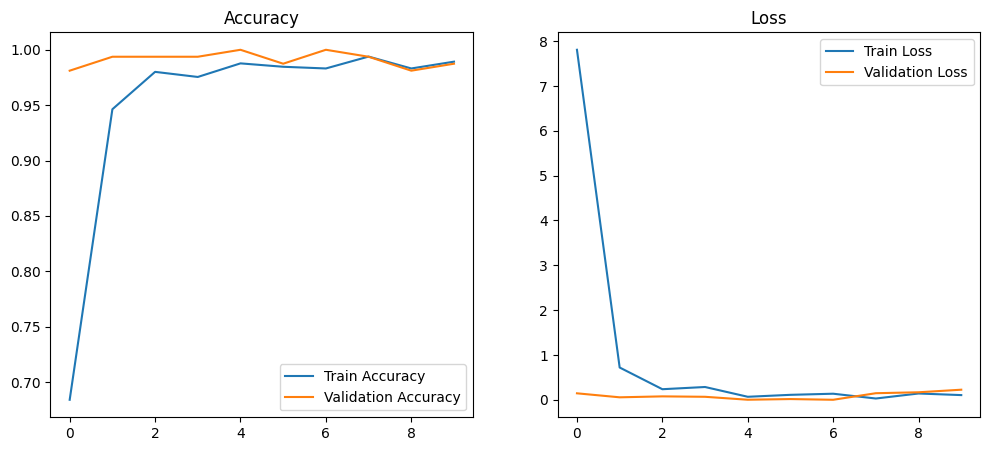

In [ ]:
import matplotlib.pyplot as plt
acc = history.history['accuracy']
val_acc = history.history['val_accuracy']
loss = history.history['loss']
val_loss = history.history['val_loss']

plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.plot(acc, label='Train Accuracy')
plt.plot(val_acc, label='Validation Accuracy')
plt.title('Accuracy')
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(loss, label='Train Loss')
plt.plot(val_loss, label='Validation Loss')
plt.title('Loss')
plt.legend()

plt.show()

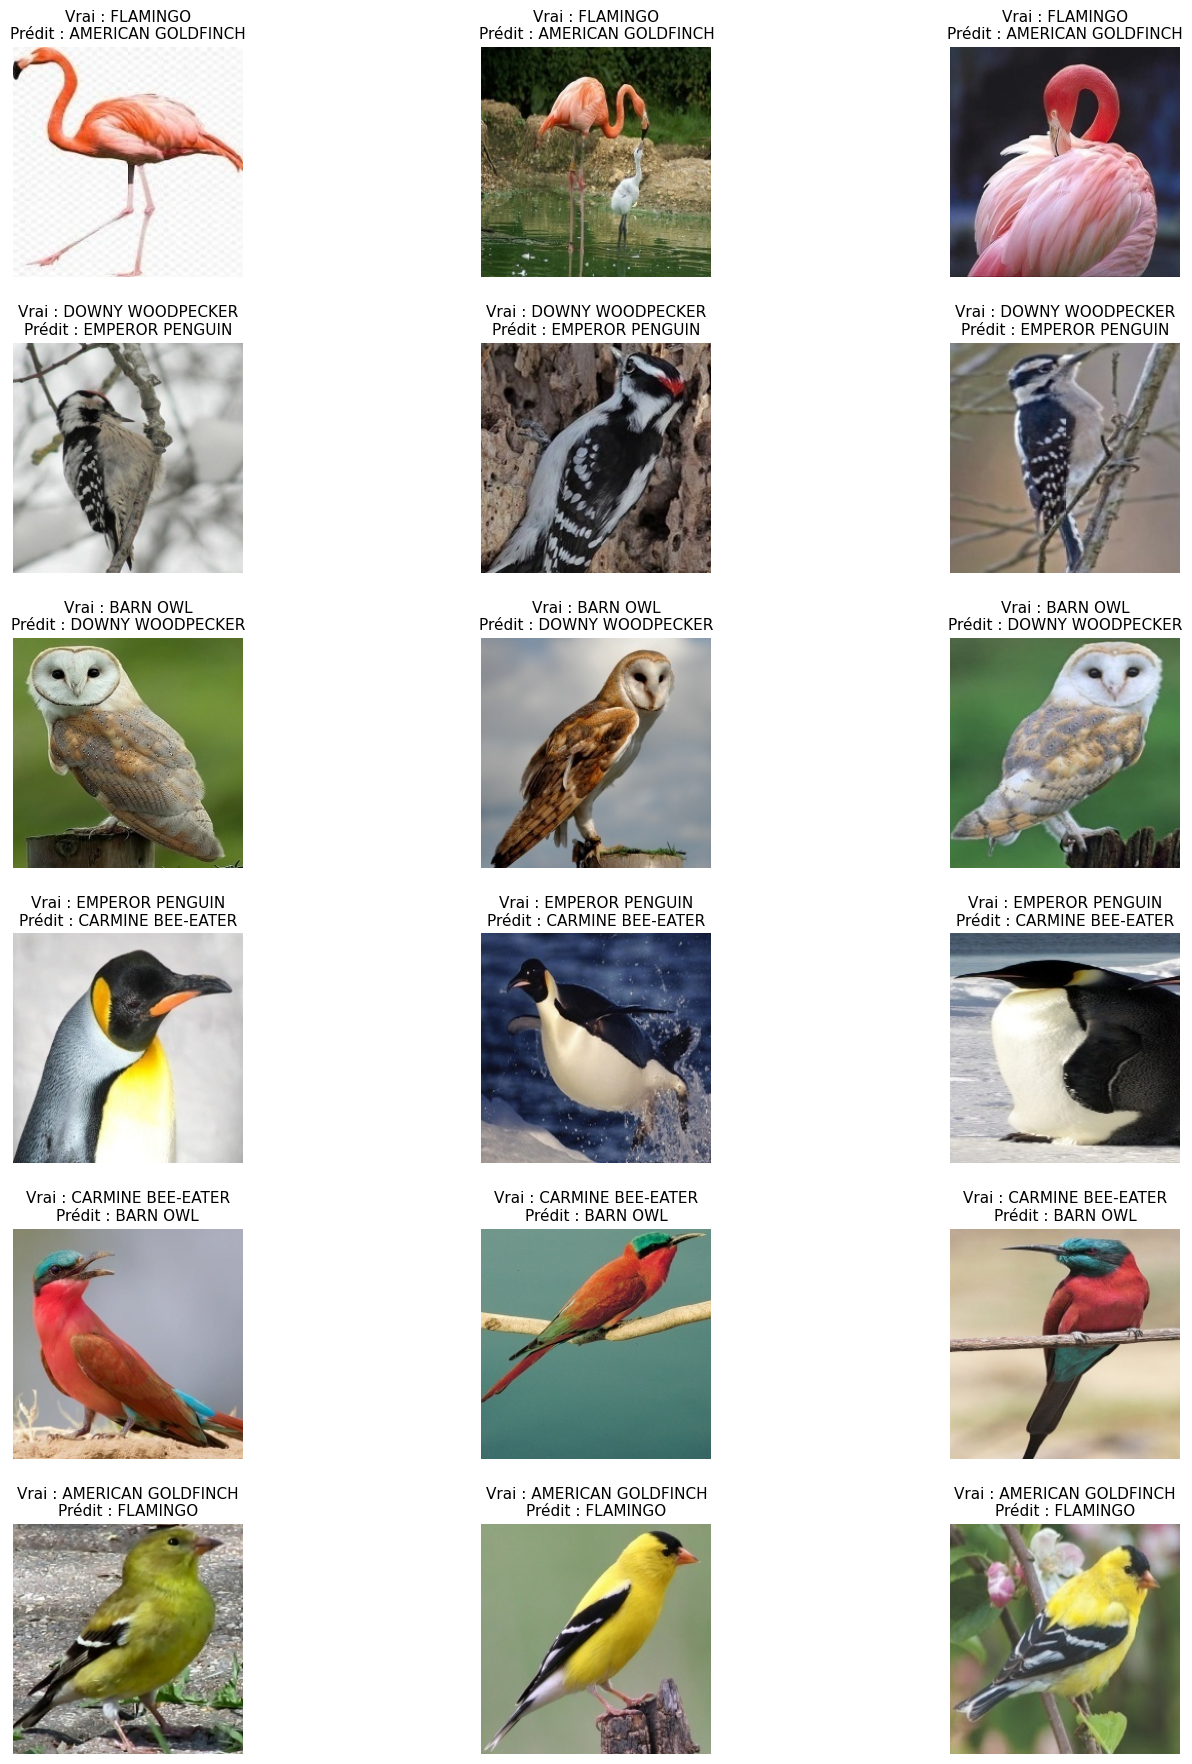

In [ ]:
import os
import random
import matplotlib.pyplot as plt
from tensorflow.keras.preprocessing import image
from tensorflow.keras.applications.vgg16 import preprocess_input
from tensorflow.keras.models import load_model
import numpy as np

# dossier dataset
base_dir = '/content/birds'

# Classes à afficher
selected_classes = [
    'FLAMINGO',
    'DOWNY WOODPECKER',
    'BARN OWL',
    'EMPEROR PENGUIN',
    'CARMINE BEE-EATER',
    'AMERICAN GOLDFINCH'
]

images_per_class = 3
all_classes = selected_classes

# Charger le modèle entraîné
best_model_path = '/content/drive/MyDrive/mon_projet_cnn/best_model.h5'
model = load_model(best_model_path)

# Crée la figure
fig, axs = plt.subplots(len(selected_classes), images_per_class, figsize=(16, 18))
if len(selected_classes) == 1:
    axs = np.expand_dims(axs, axis=0)

for row_idx, class_name in enumerate(selected_classes):
    class_dir = os.path.join(base_dir, class_name)
    image_files = [f for f in os.listdir(class_dir) if f.lower().endswith(('.jpg', '.jpeg', '.png'))]
    selected_images = random.sample(image_files, min(images_per_class, len(image_files)))

    for col_idx in range(images_per_class):
        ax = axs[row_idx, col_idx]

        if col_idx < len(selected_images):
            img_path = os.path.join(class_dir, selected_images[col_idx])
            img = image.load_img(img_path, target_size=(224, 224))  # PIL image

            # Préparation pour la prédiction
            img_array = image.img_to_array(img)
            img_array_expanded = np.expand_dims(img_array, axis=0)
            img_array_preprocessed = preprocess_input(img_array_expanded)

            # Prédiction
            prediction = model.predict(img_array_preprocessed, verbose=0)
            predicted_class = all_classes[np.argmax(prediction)]

            # Affichage de l'image
            ax.imshow(img)  # juste l'image PIL
            ax.set_title(f"Vrai : {class_name}\nPrédit : {predicted_class}", fontsize=11)
        else:
            ax.axis('off')

        ax.axis('off')

plt.tight_layout(pad=2.0)
plt.show()

In [ ]:
!ls /content/drive/MyDrive/mon_projet_cnn

 best_model.h5	'Bird Speciees Dataset'   bird-speciees-dataset.zip
